# 🥋 Poser — Dual-Stem Feature Fusion Network
**Architecture:** Keras Functional API · Two Bi-LSTM Stems · Multi-Head Attention · Anti-Leakage Clip-Level Split  
**Classes:** GedanBarai · Gyakudzuki · MaeGeri

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Aesthetics ────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_COLOR = '#0D1117'
PALETTE  = {'GedanBarai': '#00C9FF', 'Gyakudzuki': '#FF6B6B', 'MaeGeri': '#A8FF78'}

TensorFlow  : 2.18.0
Keras       : 3.12.0
GPU devices : []


## § 1 — Feature Column Definitions

In [2]:
# Upper Body: landmarks 11-22 (x,y,z,v) + angle_08 to angle_13
UPPER_COORDS = [f'{c}{i}' for i in range(11, 23) for c in ['x', 'y', 'z', 'v']]
UPPER_ANGLES = [f'angle_{i:02d}' for i in range(8, 14)]
UPPER_FEATS  = UPPER_COORDS + UPPER_ANGLES   # 48 + 6 = 54

# Lower Body: landmarks 23-32 (x,y,z,v) + angle_00 to angle_07
LOWER_COORDS = [f'{c}{i}' for i in range(23, 33) for c in ['x', 'y', 'z', 'v']]
LOWER_ANGLES = [f'angle_{i:02d}' for i in range(0, 8)]
LOWER_FEATS  = LOWER_COORDS + LOWER_ANGLES   # 40 + 8 = 48

SEQ_LEN        = 30
N_CLASSES      = 3
N_UPPER        = len(UPPER_FEATS)   # 54
N_LOWER        = len(LOWER_FEATS)   # 48

print(f'Upper features: {N_UPPER}  (target 54)')
print(f'Lower features: {N_LOWER}  (target 48)')

Upper features: 54  (target 54)
Lower features: 48  (target 48)


## § 2 — Anti-Leakage Data Loader
Split is done at **clip level**, ensuring no video's frames span both train and test sets.

In [3]:
# ── 2. Anti-Leakage SUBJECT-LEVEL Split (Practitioner Isolation) ─────────────
CSV_PATH = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\karate_normalized_base.csv"
df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# ─ Label encode ──────────────────────────────────────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['folder_label'])
CLASS_NAMES = le.classes_.tolist()
print(f'Classes: {CLASS_NAMES}')

# ─ Extract Practitioner and View ─────────────────────────────────────────────
def extract_practitioner_and_view(clip_name):
    parts = clip_name.split('_')
    # Assumes format: Move_View_Practitioner_VidNo
    if len(parts) >= 4:
        return parts[2], parts[1] # practitioner_id, view
    return "Unknown", "Unknown"

clip_meta = []
for clip_id, group in df.groupby('clip_id'):
    practitioner, view = extract_practitioner_and_view(clip_id)
    clip_meta.append({
        'clip_id': clip_id,
        'label_enc': group['label_enc'].iloc[0],
        'folder_label': group['folder_label'].iloc[0],
        'practitioner_id': practitioner,
        'view': view
    })
meta_df = pd.DataFrame(clip_meta)

# ─ Subject-Level Split (GroupShuffleSplit) ───────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
# This ensures 20% of the HUMANS go to the test set, keeping all their videos together
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(meta_df, groups=meta_df['practitioner_id']))

train_meta = meta_df.iloc[train_idx]
test_meta = meta_df.iloc[test_idx]

train_clips = train_meta['clip_id'].values
test_clips = test_meta['clip_id'].values

# ─ Verification Checks ───────────────────────────────────────────────────────
print("\n📊 TRAINING SET BALANCE:")
print(pd.crosstab(train_meta['folder_label'], train_meta['view'], margins=True))

print("\n📊 TESTING SET BALANCE:")
print(pd.crosstab(test_meta['folder_label'], test_meta['view'], margins=True))

train_practitioners = set(train_meta['practitioner_id'])
test_practitioners = set(test_meta['practitioner_id'])
leakage = train_practitioners.intersection(test_practitioners)
print(f"\n🛡️ Subject Leakage Check:")
print(f"   Train Humans: {train_practitioners}")
print(f"   Test Humans:  {test_practitioners}")
print(f"   Overlapping Humans: {'✅ ZERO' if not leakage else f'❌ LEAK DETECTED: {leakage}'}")

# ─ Reconstruct frame-level sets ───────────────────────────────────────────────
train_df = df[df['clip_id'].isin(train_clips)].sort_values(['clip_id', 'frame_idx'])
test_df  = df[df['clip_id'].isin(test_clips)].sort_values(['clip_id', 'frame_idx'])

# ─ Builder function: (N_clips, 30, features) ──────────────────────────────────
def build_sequences(sub_df, features):
    clips = sub_df['clip_id'].unique()
    X = np.zeros((len(clips), SEQ_LEN, len(features)), dtype=np.float32)
    y = np.zeros(len(clips), dtype=np.int32)
    for i, clip in enumerate(clips):
        grp = sub_df[sub_df['clip_id'] == clip].sort_values('frame_idx')
        frames = grp[features].values
        X[i, :len(frames)] = frames[:SEQ_LEN]
        y[i] = grp['label_enc'].iloc[0]
    return X, y

print('\nBuilding sequences...')
X_train_upper, y_train = build_sequences(train_df, UPPER_FEATS)
X_train_lower, _       = build_sequences(train_df, LOWER_FEATS)
X_test_upper,  y_test  = build_sequences(test_df,  UPPER_FEATS)
X_test_lower,  _       = build_sequences(test_df,  LOWER_FEATS)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print(f'X_train_upper : {X_train_upper.shape}  (target: N, 30, 54)')
print(f'X_train_lower : {X_train_lower.shape}  (target: N, 30, 48)')
print(f'X_test_upper  : {X_test_upper.shape}')
print(f'X_test_lower  : {X_test_lower.shape}')

Loaded: 10,740 rows × 149 cols
Classes: ['GedanBarai', 'Gyakudzuki', 'MaeGeri']

📊 TRAINING SET BALANCE:
view          front  side  All
folder_label                  
GedanBarai       42    64  106
Gyakudzuki       32    39   71
MaeGeri          35    66  101
All             109   169  278

📊 TESTING SET BALANCE:
view          front  side  All
folder_label                  
GedanBarai       14    13   27
Gyakudzuki       22    13   35
MaeGeri           5    13   18
All              41    39   80

🛡️ Subject Leakage Check:
   Train Humans: {'004', '027', '016', '002', '024', '018', '003', '019', '006', '015', '023', '013', '007', '017', '020', '008', '026', '011', '025', '005', '021'}
   Test Humans:  {'012', '001', '010', '014', '009', '022'}
   Overlapping Humans: ✅ ZERO

Building sequences...
X_train_upper : (278, 30, 54)  (target: N, 30, 54)
X_train_lower : (278, 30, 48)  (target: N, 30, 48)
X_test_upper  : (80, 30, 54)
X_test_lower  : (80, 30, 48)


## § 3 — Dual-Stem Fusion Architecture
```
Upper (30, 54) → BiLSTM(64) → Dropout → BiLSTM(32) ─┐
                                                       ├─ Concat → MultiHeadAttention(4 heads) → GlobalAvgPool → Dense(3)
Lower (30, 48) → BiLSTM(64) → Dropout → BiLSTM(32) ─┘
```

In [4]:
def build_dual_stem_model(
    n_upper=54, n_lower=48, seq_len=30, n_classes=3,
    lstm_units_1=64, lstm_units_2=32, num_heads=4, dropout_rate=0.4
):
    # ── Input 1: Upper Body ───────────────────────────────────────────────────
    inp_upper = keras.Input(shape=(seq_len, n_upper), name='upper_body')
    x_up = layers.Bidirectional(
        layers.LSTM(lstm_units_1, return_sequences=True),
        name='bilstm_upper_1'
    )(inp_upper)
    x_up = layers.Dropout(dropout_rate, name='drop_upper')(x_up)
    x_up = layers.Bidirectional(
        layers.LSTM(lstm_units_2, return_sequences=True),
        name='bilstm_upper_2'
    )(x_up)

    # ── Input 2: Lower Body ───────────────────────────────────────────────────
    inp_lower = keras.Input(shape=(seq_len, n_lower), name='lower_body')
    x_lo = layers.Bidirectional(
        layers.LSTM(lstm_units_1, return_sequences=True),
        name='bilstm_lower_1'
    )(inp_lower)
    x_lo = layers.Dropout(dropout_rate, name='drop_lower')(x_lo)
    x_lo = layers.Bidirectional(
        layers.LSTM(lstm_units_2, return_sequences=True),
        name='bilstm_lower_2'
    )(x_lo)

    # ── Fusion Node ───────────────────────────────────────────────────────────
    fused = layers.Concatenate(axis=-1, name='fusion_concat')([x_up, x_lo])  # (batch, 30, 64+64)

    # ── Global Self-Attention (Sensei's Eye) ──────────────────────────────────
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=fused.shape[-1] // num_heads,
        name='sensei_attention'
    )(fused, fused)                               # self-attention
    attn_out = layers.LayerNormalization(name='attn_norm')(attn_out + fused)  # residual
    attn_out = layers.Dropout(0.3, name='drop_attn')(attn_out)

    # ── Readout ───────────────────────────────────────────────────────────────
    pooled = layers.GlobalAveragePooling1D(name='global_avg_pool')(attn_out)
    pooled = layers.Dense(64, activation='relu', name='pre_output')(pooled)
    pooled = layers.Dropout(0.3)(pooled)
    output = layers.Dense(n_classes, activation='softmax', name='technique_output')(pooled)

    model = Model(inputs=[inp_upper, inp_lower], outputs=output, name='DualStemFusion')
    return model

model = build_dual_stem_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "DualStemFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ upper_body          │ (None, 30, 54)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_body          │ (None, 30, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_upper_1      │ (None, 30, 128)   │     60,928 │ upper_body[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_lower_1      │ (None, 30, 128)   │     57,856 │ lower_body[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_upper          │ (None, 30, 128)   │          0 │ bilstm_upper_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lower          │ (None, 30, 128)   │          0 │ bilstm_lower_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_upper_2      │ (None, 30, 64)    │     41,216 │ drop_upper[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_lower_2      │ (None, 30, 64)    │     41,216 │ drop_lower[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 30, 128)   │          0 │ bilstm_upper_2[0… │
│ (Concatenate)       │                   │            │ bilstm_lower_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensei_attention    │ (None, 30, 128)   │     66,048 │ fusion_concat[0]… │
│ (MultiHeadAttentio… │                   │            │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ sensei_attention… │
│                     │                   │            │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 30, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_attn (Dropout) │ (None, 30, 128)   │          0 │ attn_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 128)       │          0 │ drop_attn[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_output (Dense)  │ (None, 64)        │      8,256 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ pre_output[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ technique_output    │ (None, 3)         │        195 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,971 (1.05 MB)

 Trainable params: 275,971 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

## § 4 — Training

In [5]:
CKPT_PATH = 'dual_stem_best.keras'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

history = model.fit(
    x=[X_train_upper, X_train_lower],
    y=y_train_cat,
    validation_data=([X_test_upper, X_test_lower], y_test_cat),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4324 - loss: 1.3698
Epoch 1: val_accuracy improved from None to 0.67500, saving model to dual_stem_best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 307ms/step - accuracy: 0.4712 - loss: 1.2079 - val_accuracy: 0.6750 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7170 - loss: 0.7538
Epoch 2: val_accuracy improved from 0.67500 to 0.68750, saving model to dual_stem_best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.7482 - loss: 0.6725 - val_accuracy: 0.6875 - val_loss: 0.7876 - learning_rate: 0.0010
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8452 - loss: 0.4972
Epoch 3: val_accuracy improved from 0.68750 to 0.70000, saving model to dual_stem_best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8561 - loss: 0.4400 - val_accuracy: 0.7000 - val_loss: 0.6495 - learning_rate: 0.0010
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Upper_Stem_Input    │ (None, 30, 54)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Lower_Stem_Input    │ (None, 30, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 128)   │     60,928 │ Upper_Stem_Input… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 30, 128)   │     57,856 │ Lower_Stem_Input… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 128)   │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 64)    │     41,216 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 30, 64)    │     41,216 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 30, 128)   │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │    131,968 │ concatenate[0][0… │
│ (MultiHeadAttentio… │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_5[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action_classificat… │ (None, 3)         │        195 │ dropout_6[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 341,635 (1.30 MB)

 Trainable params: 341,635 (1.30 MB)

 Non-trainable params: 0 (0.00 B)


🏋️ Starting Dual-Stem Training Loop...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - accuracy: 0.5144 - loss: 0.9659 - val_accuracy: 0.6750 - val_loss: 0.7820 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8633 - loss: 0.3536 - val_accuracy: 0.8500 - val_loss: 0.5583 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9101 - loss: 0.2904 - val_accuracy: 0.7125 - val_loss: 1.0219 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9460 - loss: 0.1399 - val_accuracy: 0.8875 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9820 - loss: 0.0530 - val_accuracy: 0.9250 - val_loss: 0.2774 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9892 - loss: 0.0481 - val_accuracy: 0.9625 - val_loss: 0.2608 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms

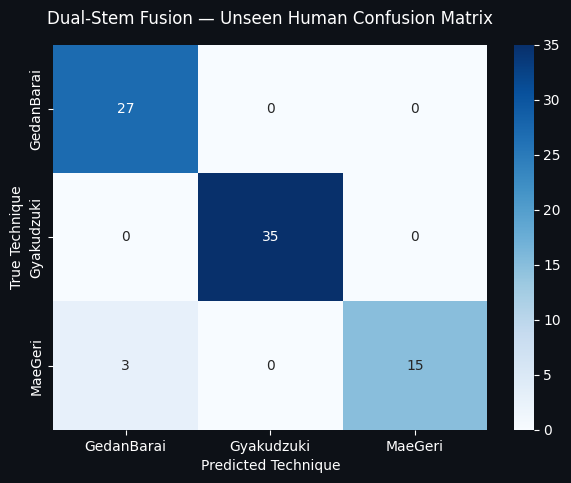

In [6]:
# ── 3. Build Dual-Stem Fusion Architecture ────────────────────────────────────
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, concatenate, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def build_fusion_model(seq_len, n_upper, n_lower, n_classes):
    # ─ A. Parallel Inputs
    in_upper = Input(shape=(seq_len, n_upper), name="Upper_Stem_Input")
    in_lower = Input(shape=(seq_len, n_lower), name="Lower_Stem_Input")
    
    # ─ B. Upper Body Track (Arms)
    u = Bidirectional(LSTM(64, return_sequences=True))(in_upper)
    u = Dropout(0.4)(u)
    u_out = Bidirectional(LSTM(32, return_sequences=True))(u)
    
    # ─ C. Lower Body Track (Legs)
    l = Bidirectional(LSTM(64, return_sequences=True))(in_lower)
    l = Dropout(0.4)(l)
    l_out = Bidirectional(LSTM(32, return_sequences=True))(l)
    
    # ─ D. The Fusion Node
    merged = concatenate([u_out, l_out], axis=-1)
    
    # ─ E. Global Self-Attention (The "Sensei's Eye")
    # Learns to dynamically ignore the static legs during punches/blocks, but focus on them for kicks
    attn = MultiHeadAttention(num_heads=4, key_dim=64)(merged, merged)
    attn = Dropout(0.3)(attn)
    
    # ─ F. Classification Head
    pooled = GlobalAveragePooling1D()(attn)
    dense = Dense(64, activation='relu')(pooled)
    dense = Dropout(0.3)(dense)
    output = Dense(n_classes, activation='softmax', name='action_classification')(dense)
    
    model = Model(inputs=[in_upper, in_lower], outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate the model
model = build_fusion_model(seq_len=30, n_upper=54, n_lower=48, n_classes=len(CLASS_NAMES))
model.summary()

# ── 4. Execute Training Sprint ────────────────────────────────────────────────
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5, monitor='val_loss', verbose=1)
]

print("\n🏋️ Starting Dual-Stem Training Loop...")
history = model.fit(
    [X_train_upper, X_train_lower], y_train_cat,
    validation_data=([X_test_upper, X_test_lower], y_test_cat), # Testing directly on the Unseen Humans
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# ── 5. Honest Evaluation & Confusion Matrix ───────────────────────────────────
print("\n🔍 Evaluating on Unseen Practitioner Test Set...")
y_pred_prob = model.predict([X_test_upper, X_test_lower])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n🏆 REAL-WORLD CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5), facecolor='#0D1117')
ax = plt.gca()
ax.set_facecolor('#161B22')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
plt.title('Dual-Stem Fusion — Unseen Human Confusion Matrix', color='white', pad=15)
plt.ylabel('True Technique', color='white')
plt.xlabel('Predicted Technique', color='white')
plt.tick_params(colors='white')
plt.show()

## § 5 — Learning Curves

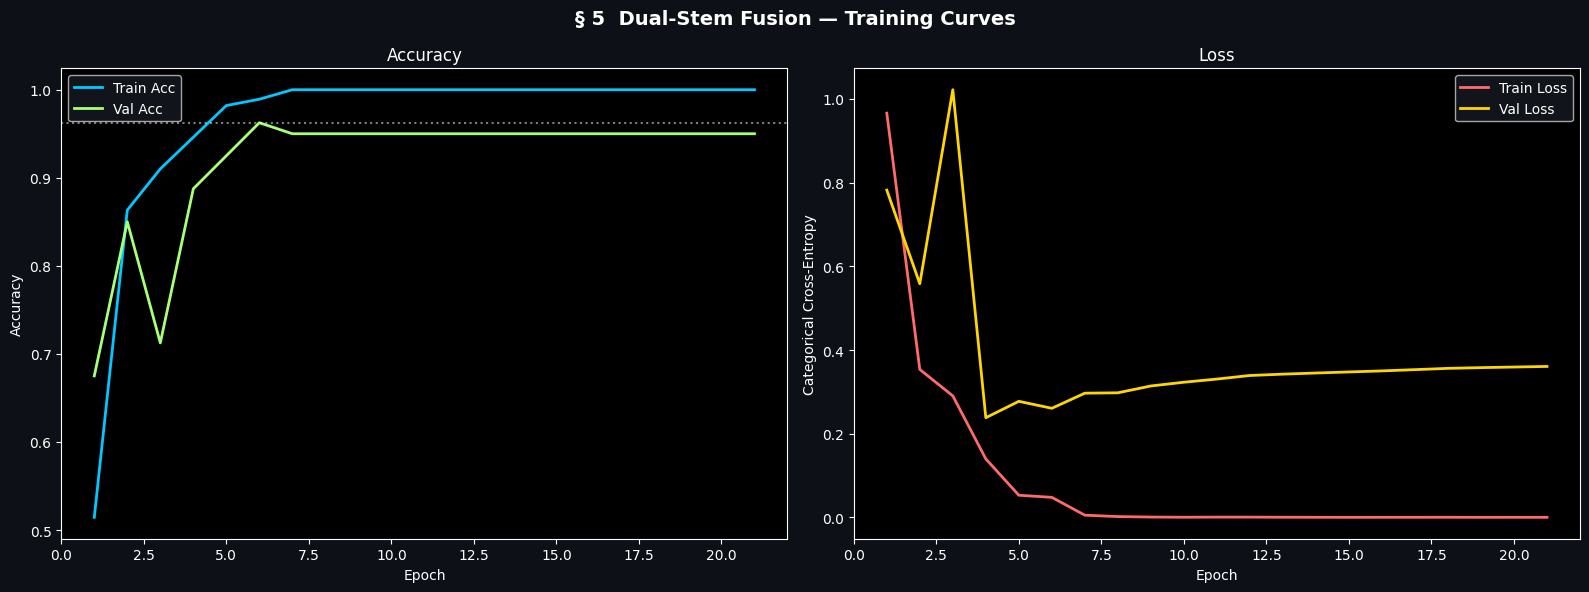

Best Val Accuracy : 0.9625
Best Val Loss     : 0.2383


In [7]:
hist = history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle('§ 5  Dual-Stem Fusion — Training Curves', fontsize=14, fontweight='bold', color='white')

# Accuracy
axes[0].plot(epochs_ran, hist['accuracy'],     color='#00C9FF', linewidth=2, label='Train Acc')
axes[0].plot(epochs_ran, hist['val_accuracy'], color='#A8FF78', linewidth=2, label='Val Acc')
axes[0].set_title('Accuracy', color='white')
axes[0].set_xlabel('Epoch', color='white')
axes[0].set_ylabel('Accuracy', color='white')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#161B22', labelcolor='white')
axes[0].axhline(y=max(hist['val_accuracy']), color='white', linestyle=':', alpha=0.5,
                label=f'Best Val: {max(hist["val_accuracy"]):.3f}')

# Loss
axes[1].plot(epochs_ran, hist['loss'],     color='#FF6B6B', linewidth=2, label='Train Loss')
axes[1].plot(epochs_ran, hist['val_loss'], color='#FFD700', linewidth=2, label='Val Loss')
axes[1].set_title('Loss', color='white')
axes[1].set_xlabel('Epoch', color='white')
axes[1].set_ylabel('Categorical Cross-Entropy', color='white')
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#161B22', labelcolor='white')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print(f'Best Val Accuracy : {max(hist["val_accuracy"]):.4f}')
print(f'Best Val Loss     : {min(hist["val_loss"]):.4f}')

## § 6 — Evaluation: Confusion Matrix & Classification Report

=== Classification Report ===
              precision    recall  f1-score   support

  GedanBarai     0.9000    1.0000    0.9474        27
  Gyakudzuki     1.0000    1.0000    1.0000        35
     MaeGeri     1.0000    0.8333    0.9091        18

    accuracy                         0.9625        80
   macro avg     0.9667    0.9444    0.9522        80
weighted avg     0.9662    0.9625    0.9618        80



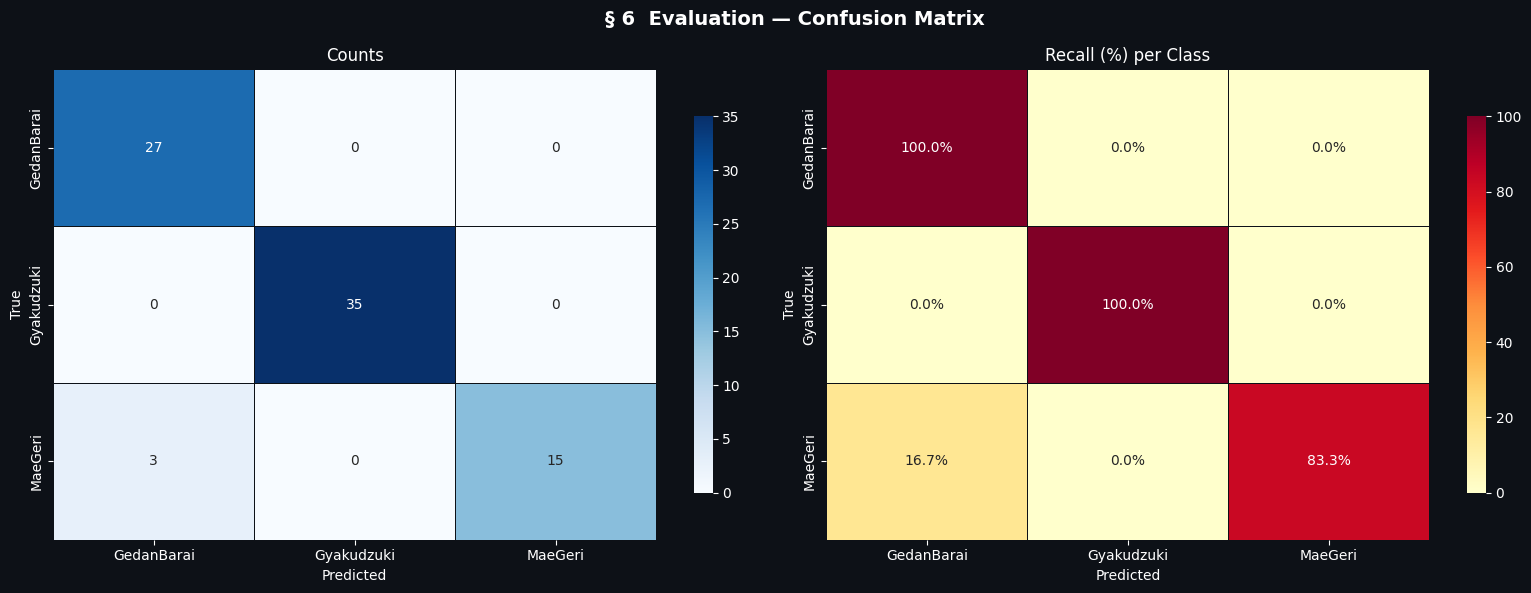


Test Accuracy : 96.25%
Test Loss     : 0.2608


In [8]:
# Predictions
y_pred_probs = model.predict([X_test_upper, X_test_lower], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test   # integer-encoded ground truth

# ─ Classification Report ──────────────────────────────────────────────────────
print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ─ Confusion Matrix (Seaborn) ────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle('§ 6  Evaluation — Confusion Matrix', fontsize=14, fontweight='bold', color='white')

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='#0D1117', ax=axes[0],
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Counts', color='white')
axes[0].set_xlabel('Predicted', color='white')
axes[0].set_ylabel('True', color='white')
axes[0].tick_params(colors='white')

# Percentage
annot_pct = np.array([[f'{v:.1f}%' for v in row] for row in cm_pct])
sns.heatmap(
    cm_pct, annot=annot_pct, fmt='', cmap='YlOrRd',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='#0D1117', ax=axes[1],
    vmin=0, vmax=100, cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Recall (%) per Class', color='white')
axes[1].set_xlabel('Predicted', color='white')
axes[1].set_ylabel('True', color='white')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# Overall test accuracy
test_loss, test_acc = model.evaluate(
    [X_test_upper, X_test_lower], y_test_cat, verbose=0
)
print(f'\nTest Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

## § 7 — Save Model & Export

In [9]:
import json, datetime

SAVE_DIR = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save full model
model_path = os.path.join(SAVE_DIR, 'dual_stem_fusion.keras')
model.save(model_path)
print(f'✅ Model saved → {model_path}')

# Save label encoder classes
meta = {
    'classes': CLASS_NAMES,
    'upper_features': UPPER_FEATS,
    'lower_features': LOWER_FEATS,
    'seq_len': SEQ_LEN,
    'test_accuracy': float(test_acc),
    'trained_at': datetime.datetime.now().isoformat()
}
meta_path = os.path.join(SAVE_DIR, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'✅ Metadata saved → {meta_path}')
print(f'\n🎯 Final Test Accuracy: {test_acc*100:.2f}%')

✅ Model saved → D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\dual_stem_fusion.keras
✅ Metadata saved → D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\model_metadata.json

🎯 Final Test Accuracy: 96.25%


⚙️ Recombining features for the Old Standard Model...
Old Model Train Shape: (278, 30, 102) (N_Clips, 30 Frames, 102 Features)

🏗️ Old Model Architecture Built. Starting training...
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 11.

🏆 OLD MODEL (STANDARD BI-LSTM) RESULTS
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step

📊 Classification Report (Old Model):
              precision    recall  f1-score   support

  GedanBarai       0.89      0.93      0.91        27
  Gyakudzuki       1.00      0.89      0.94        35
     MaeGeri       0.71      0.83      0.77        18

    accuracy                           0.89        80
   macro avg       0.87      0.88      0.87        80
weighted avg       0.90      0.89      0.89        80



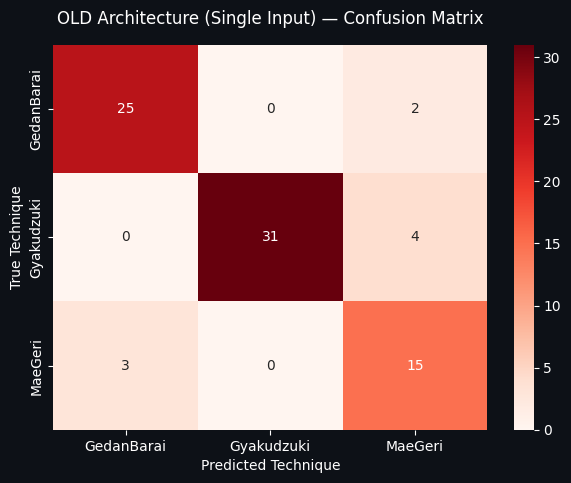

In [10]:
# ==============================================================================
# 🥊 HEAD-TO-HEAD TOURNAMENT: Standard Bi-LSTM (Old) vs. Dual-Stem (New)
# Purpose: Trains the traditional single-input model on the exact same 
#          leak-proof dataset to prove the necessity of the Dual-Stem split.
# ==============================================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
import numpy as np

print("⚙️ Recombining features for the Old Standard Model...")
# Glue the Upper and Lower features back together (Shape goes from 54 & 48 -> 102)
X_train_full = np.concatenate([X_train_upper, X_train_lower], axis=2)
X_test_full = np.concatenate([X_test_upper, X_test_lower], axis=2)

print(f"Old Model Train Shape: {X_train_full.shape} (N_Clips, 30 Frames, 102 Features)")

# ── 1. Build the Old Standard Sequential Bi-LSTM ──────────────────────────────
old_model = Sequential([
    Input(shape=(30, 102), name="Full_Body_Input"),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(CLASS_NAMES), activation='softmax', name="action_classification")
])

old_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\n🏗️ Old Model Architecture Built. Starting training...")

# ── 2. Train the Old Model ────────────────────────────────────────────────────
callbacks_old = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5, monitor='val_loss', verbose=0)
]

history_old = old_model.fit(
    X_train_full, y_train_cat,
    validation_data=(X_test_full, y_test_cat), 
    epochs=100,
    batch_size=16,
    callbacks=callbacks_old,
    verbose=0 # Hiding epoch logs to keep your notebook clean, will just print final result
)

# ── 3. Evaluate the Old Model ─────────────────────────────────────────────────
print("\n" + "="*50)
print("🏆 OLD MODEL (STANDARD BI-LSTM) RESULTS")
print("="*50)

y_pred_prob_old = old_model.predict(X_test_full)
y_pred_old = np.argmax(y_pred_prob_old, axis=1)

print("\n📊 Classification Report (Old Model):")
print(classification_report(y_true, y_pred_old, target_names=CLASS_NAMES))

# ── 4. Plot the Old Confusion Matrix ──────────────────────────────────────────
cm_old = confusion_matrix(y_true, y_pred_old)
plt.figure(figsize=(7, 5), facecolor='#0D1117')
ax = plt.gca()
ax.set_facecolor('#161B22')
sns.heatmap(cm_old, annot=True, fmt='d', cmap='Reds', # Using RED to distinguish from the new model's BLUE matrix
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
plt.title('OLD Architecture (Single Input) — Confusion Matrix', color='white', pad=15)
plt.ylabel('True Technique', color='white')
plt.xlabel('Predicted Technique', color='white')
plt.tick_params(colors='white')
plt.show()

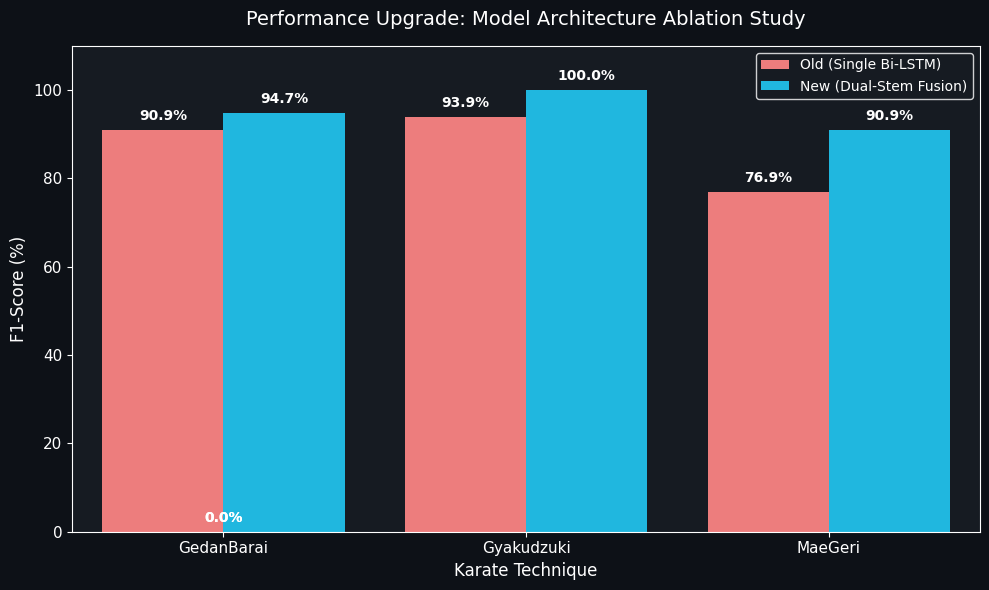

In [11]:
# ==============================================================================
# 📊 FINAL VISUALIZATION: Dual-Stem vs Single Bi-LSTM F1-Score Comparison
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Extract dictionaries of the performance metrics
report_new = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_old = classification_report(y_true, y_pred_old, target_names=CLASS_NAMES, output_dict=True)

# Format into a clean DataFrame
comparison_data = []
for cls in CLASS_NAMES:
    comparison_data.append({'Technique': cls, 'F1-Score': report_old[cls]['f1-score'] * 100, 'Model': 'Old (Single Bi-LSTM)'})
    comparison_data.append({'Technique': cls, 'F1-Score': report_new[cls]['f1-score'] * 100, 'Model': 'New (Dual-Stem Fusion)'})

comp_df = pd.DataFrame(comparison_data)

# Plotting
plt.figure(figsize=(10, 6), facecolor='#0D1117')
ax = plt.gca()
ax.set_facecolor('#161B22')

sns.barplot(
    data=comp_df, 
    x='Technique', 
    y='F1-Score', 
    hue='Model', 
    palette={'Old (Single Bi-LSTM)': '#FF6B6B', 'New (Dual-Stem Fusion)': '#00C9FF'},
    ax=ax
)

plt.title('Performance Upgrade: Model Architecture Ablation Study', color='white', fontsize=14, pad=15)
plt.ylabel('F1-Score (%)', color='white', fontsize=12)
plt.xlabel('Karate Technique', color='white', fontsize=12)
plt.ylim(0, 110) # Give headroom for the legend
plt.tick_params(colors='white', labelsize=11)

# Style the Legend
legend = plt.legend(facecolor='#161B22', edgecolor='white', labelcolor='white')
plt.setp(legend.texts, color='white')

# Add exact percentage numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\model_comparison.png", dpi=150, facecolor='#0D1117')
plt.show()